# 02 – Computer Vision: Car Brand Classification

**Task:** Multi-class image classification — predict the car brand from a photo.  
**Approach:** Transfer learning with a ResNet18 backbone pretrained on ImageNet.  
**Dataset:** 64 467 car images across 42 brands, stored in a flat folder.

---
## Section 1 – Setup & Imports

We import all required libraries, fix every source of randomness for reproducibility, and detect the best available compute device.  
Setting `SEED = 42` everywhere ensures that splits, augmentation, and weight initialisation are identical across runs.

In [1]:
import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision import models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# --- Global constants ---
SEED = 42                # used for every random call
IMG_DIR = '../data/raw/Auto_Bilder'
# Set MAX_PER_CLASS to an integer (e.g. 200) to subsample per brand and speed up
# training on CPU.  None = use all available images.
MAX_PER_CLASS = None

# Fix all random seeds for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
# Select best available device: CUDA > Apple MPS > CPU
def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

device = get_device()
print(f'Using device: {device}')

Using device: mps


---
## Section 2 – Data Loading & Exploration

All images live in a single flat folder; the brand name is encoded in the filename as the first token before the first underscore (e.g. `Alfa Romeo_4C Spider_2020_...jpg` → **Alfa Romeo**).  
We scan the folder, extract labels, visualise the class distribution, and filter out any brand with fewer than 50 images to avoid severe class imbalance during training.

Total images found: 64467
Unique brands:      42


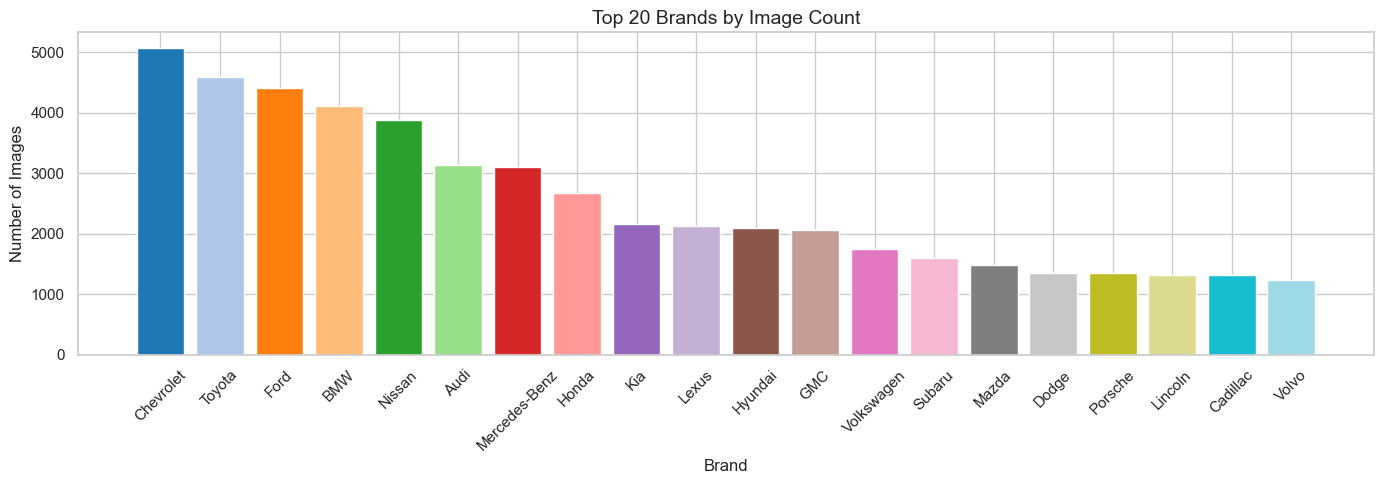

In [3]:
# Scan all .jpg files and extract brand labels from filenames
all_files = sorted([f for f in os.listdir(IMG_DIR) if f.lower().endswith('.jpg')])
# Brand = everything before the first underscore (handles multi-word brands like 'Alfa Romeo')
all_brands = [f.split('_')[0] for f in all_files]
all_paths  = [os.path.join(IMG_DIR, f) for f in all_files]

print(f'Total images found: {len(all_files)}')
print(f'Unique brands:      {len(set(all_brands))}')

# Count images per brand
brand_counts = pd.Series(all_brands).value_counts()

# Bar chart: top 20 brands by image count
fig, ax = plt.subplots(figsize=(14, 5))
top20 = brand_counts.head(20)
ax.bar(top20.index, top20.values, color=sns.color_palette('tab20', 20))
ax.set_title('Top 20 Brands by Image Count', fontsize=14)
ax.set_xlabel('Brand')
ax.set_ylabel('Number of Images')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

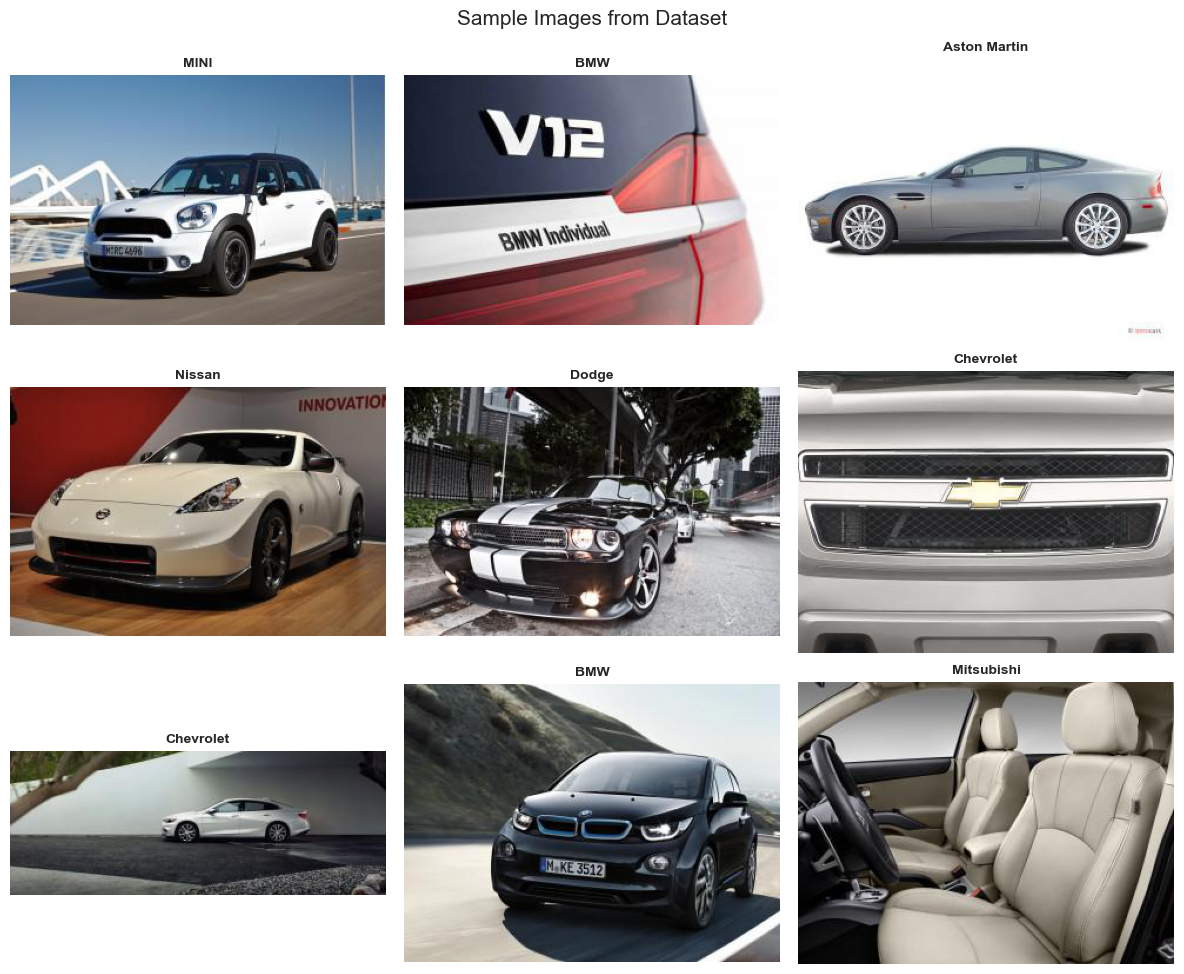

In [4]:
# Show 9 sample images in a 3x3 grid with their brand labels
random.seed(SEED)
sample_idx = random.sample(range(len(all_files)), 9)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for ax, i in zip(axes.flatten(), sample_idx):
    img = Image.open(all_paths[i]).convert('RGB')
    ax.imshow(img)
    ax.set_title(all_brands[i], fontsize=10, fontweight='bold')
    ax.axis('off')
plt.suptitle('Sample Images from Dataset', fontsize=15)
plt.tight_layout()
plt.show()

In [5]:
# Keep only brands with at least 50 images
MIN_IMAGES = 50
valid_brands = set(brand_counts[brand_counts >= MIN_IMAGES].index)

filtered_paths  = [p for p, b in zip(all_paths, all_brands)  if b in valid_brands]
filtered_labels = [b for b in all_brands if b in valid_brands]

print(f'Brands with >= {MIN_IMAGES} images: {len(valid_brands)}')
print(f'Images remaining after filtering: {len(filtered_paths)}')

# Optional per-class subsampling to speed up training on CPU
if MAX_PER_CLASS is not None:
    class_buckets = defaultdict(list)
    for i, label in enumerate(filtered_labels):
        class_buckets[label].append(i)

    random.seed(SEED)
    keep_idx = []
    for brand, idxs in class_buckets.items():
        keep_idx.extend(random.sample(idxs, min(MAX_PER_CLASS, len(idxs))))
    keep_idx.sort()

    filtered_paths  = [filtered_paths[i]  for i in keep_idx]
    filtered_labels = [filtered_labels[i] for i in keep_idx]
    print(f'After subsampling (MAX_PER_CLASS={MAX_PER_CLASS}): {len(filtered_paths)} images')

Brands with >= 50 images: 42
Images remaining after filtering: 64467


---
## Section 3 – Image Preprocessing & Data Augmentation

Raw images must be transformed into fixed-size tensors before feeding them into the network.  
We define two transform pipelines — one for training (with augmentation) and one for validation/test (without augmentation).  
Augmentation artificially increases training diversity to reduce overfitting without collecting new images.

In [6]:
IMG_SIZE = 224  # Required input size for ResNet pretrained on ImageNet

# Training transform: augmentation + normalisation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),               # cars appear mirrored equally often
    transforms.RandomRotation(10),                   # slight tilt variation
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.2),          # lighting / colour variation
    transforms.ToTensor(),
    # Normalise with ImageNet statistics — required because ResNet weights
    # were fit to images normalised with these exact values.
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Validation / test transform: deterministic — no augmentation
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print('Transforms defined successfully.')

Transforms defined successfully.


### Why these augmentations and why ImageNet normalisation?

**RandomHorizontalFlip** — Car photos in the dataset come from multiple angles. Flipping horizontally doubles the effective variety at zero cost and is visually plausible (a car looks the same mirrored).  

**RandomRotation(10°)** — Real-world photos are rarely perfectly level. Small rotations teach the model rotational robustness without distorting the brand-identifying features (grille, logo, body shape).  

**ColorJitter** — Lighting conditions, camera white-balance, and image compression vary across sources. Randomly perturbing brightness, contrast, and saturation stops the model from memorising lighting artifacts instead of car features.  

**We do NOT augment the validation/test set** — those transforms must be deterministic so that metrics are comparable across runs.  

**ImageNet normalisation (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`)** — ResNet18's convolutional filters were optimised for inputs in this normalised space. If we feed images with a different pixel distribution, the pretrained activations are off-scale and transfer learning breaks down. Using the same statistics as training aligns our data with the distribution the backbone already understands.

In [7]:
# Encode string labels to consecutive integers
le = LabelEncoder()
encoded_labels = le.fit_transform(filtered_labels)
class_names = list(le.classes_)   # index → brand name
num_classes  = len(class_names)
print(f'Number of classes: {num_classes}')


class CarBrandDataset(Dataset):
    """Loads car images from a flat directory with pre-computed labels."""

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # .convert('RGB') handles grayscale or RGBA images gracefully
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])


# Stratified 70 / 15 / 15 split
X_arr = np.array(filtered_paths)
y_arr = encoded_labels

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_arr, y_arr, test_size=0.15, random_state=SEED, stratify=y_arr
)
# val fraction relative to trainval = 0.15 / 0.85 ≈ 0.176
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=round(0.15 / 0.85, 4),
    random_state=SEED,
    stratify=y_trainval
)

print(f'Train set:      {len(X_train):>6} images')
print(f'Validation set: {len(X_val):>6} images')
print(f'Test set:       {len(X_test):>6} images')

# Datasets
train_dataset = CarBrandDataset(X_train, y_train, transform=train_transform)
val_dataset   = CarBrandDataset(X_val,   y_val,   transform=val_transform)
test_dataset  = CarBrandDataset(X_test,  y_test,  transform=val_transform)

BATCH_SIZE = 32
# num_workers=0 avoids multiprocessing issues inside Jupyter notebooks
pin = (device.type == 'cuda')  # pin_memory only helps with CUDA
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=pin)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=pin)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=pin)

print(f'\nDataLoaders ready  |  batch_size={BATCH_SIZE}')

Number of classes: 42
Train set:       45124 images
Validation set:   9672 images
Test set:         9671 images

DataLoaders ready  |  batch_size=32


---
## Section 4 – Transfer Learning with Pretrained Model

We load ResNet18 pretrained on ImageNet, freeze the convolutional backbone, and replace only the final classifier layer with one that outputs scores for our 42 brand classes.  
In Phase 1 we train **only the new head** — this is fast and prevents the pretrained features from being destroyed by large gradient updates early on.

In [8]:
# Load ResNet18 pretrained on ImageNet
# torchvision >= 0.13 uses weights=; older API uses pretrained=True
try:
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
except AttributeError:
    model = models.resnet18(pretrained=True)

# Step 1: Freeze ALL pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Step 2: Replace the final FC layer to match our number of classes
# ResNet18 final layer: Linear(512, 1000) → Linear(512, num_classes)
in_features = model.fc.in_features          # 512
model.fc = nn.Linear(in_features, num_classes)  # new layer is trainable by default

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'ResNet18 loaded  |  classes={num_classes}')
print(f'Trainable params:  {trainable:>10,}')
print(f'Total params:      {total:>10,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/dm7op/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:05<00:00, 8.02MB/s]


ResNet18 loaded  |  classes=42
Trainable params:      21,546
Total params:      11,198,058


### Why Transfer Learning instead of training from scratch?

**Training from scratch** on 60K images would require many more epochs and likely overfit — car images share low-level features (edges, textures, colour gradients) with the 1.2 million ImageNet images the ResNet was trained on.  

**Transfer learning** re-uses those learned feature detectors. The frozen convolutional layers act as a powerful, fixed feature extractor; we only need to learn the final classification weights.  

**Two-phase strategy** (as taught in the course):
1. **Frozen backbone (Phase 1):** Train only the new FC head. The backbone weights are protected from destructive large-gradient updates on an unfamiliar task. This converges quickly and establishes a good starting point for the head.  
2. **Fine-tuning (Phase 2):** Unfreeze all layers and train end-to-end with a small learning rate. This lets the backbone subtly adapt its features to the specific visual differences between car brands (grille shape, badge placement, headlight design) while not forgetting its general visual knowledge.

In [9]:
# Loss, optimizer, and scheduler for Phase 1
criterion       = nn.CrossEntropyLoss()
# Only optimise the new FC layer in Phase 1
optimizer_p1    = optim.Adam(model.fc.parameters(), lr=0.001)
# Halve the LR every 2 epochs to stabilise convergence
scheduler_p1    = StepLR(optimizer_p1, step_size=2, gamma=0.5)


# ---------- training helpers ----------

def train_epoch(model, loader, criterion, optimizer):
    """One training epoch; returns average loss."""
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion):
    """Evaluate model; returns (avg_loss, accuracy)."""
    model.eval()
    total_loss = 0.0
    correct    = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            total_loss += criterion(outputs, labels).item() * images.size(0)
            correct    += outputs.argmax(dim=1).eq(labels).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n


# ---------- Phase 1: frozen backbone, 5 epochs ----------
EPOCHS_P1 = 5
hist_p1 = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print('=== Phase 1: Frozen backbone — training FC head only ===')
for epoch in range(1, EPOCHS_P1 + 1):
    tr_loss          = train_epoch(model, train_loader, criterion, optimizer_p1)
    vl_loss, vl_acc  = evaluate(model, val_loader, criterion)
    scheduler_p1.step()

    hist_p1['train_loss'].append(tr_loss)
    hist_p1['val_loss'].append(vl_loss)
    hist_p1['val_acc'].append(vl_acc)

    print(f'  Epoch {epoch}/{EPOCHS_P1}  |  '
          f'Train Loss: {tr_loss:.4f}  |  '
          f'Val Loss: {vl_loss:.4f}  |  '
          f'Val Acc: {vl_acc:.4f}')

=== Phase 1: Frozen backbone — training FC head only ===
  Epoch 1/5  |  Train Loss: 3.1460  |  Val Loss: 2.9519  |  Val Acc: 0.1943
  Epoch 2/5  |  Train Loss: 2.9008  |  Val Loss: 2.8895  |  Val Acc: 0.2171
  Epoch 3/5  |  Train Loss: 2.7743  |  Val Loss: 2.8000  |  Val Acc: 0.2290
  Epoch 4/5  |  Train Loss: 2.7516  |  Val Loss: 2.8299  |  Val Acc: 0.2186
  Epoch 5/5  |  Train Loss: 2.6984  |  Val Loss: 2.7622  |  Val Acc: 0.2376


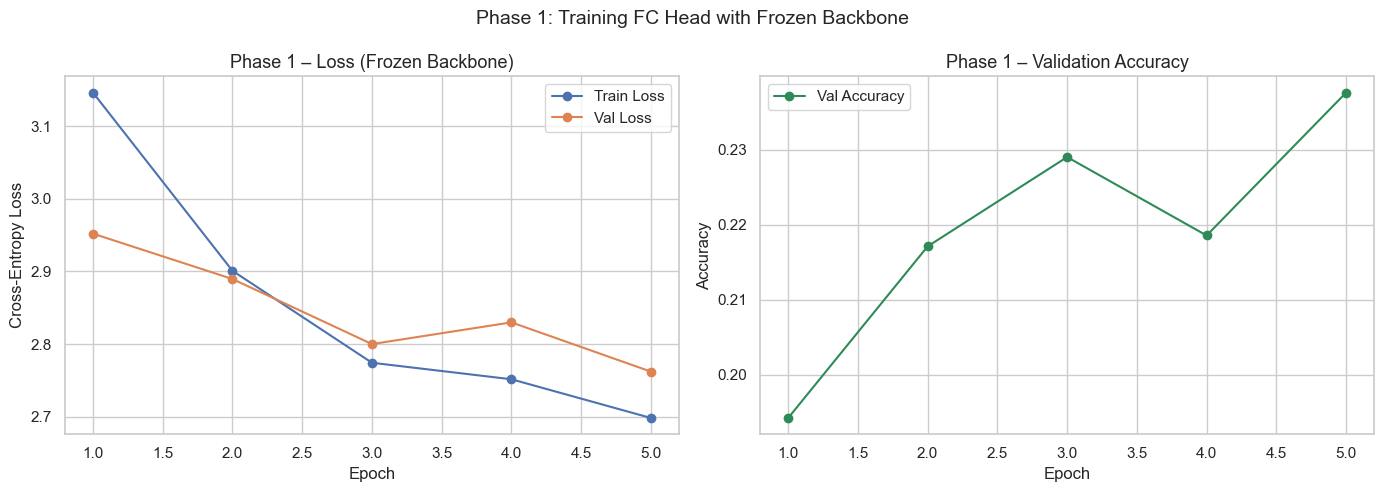

In [10]:
# Plot Phase 1 training curves
ep1 = range(1, EPOCHS_P1 + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ep1, hist_p1['train_loss'], marker='o', label='Train Loss')
ax1.plot(ep1, hist_p1['val_loss'],   marker='o', label='Val Loss')
ax1.set_title('Phase 1 – Loss (Frozen Backbone)', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend()

ax2.plot(ep1, hist_p1['val_acc'], marker='o', color='seagreen', label='Val Accuracy')
ax2.set_title('Phase 1 – Validation Accuracy', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.suptitle('Phase 1: Training FC Head with Frozen Backbone', fontsize=14)
plt.tight_layout()
plt.show()

---
## Section 5 – Fine-Tuning

After the head has converged, we unfreeze the entire network and train all layers end-to-end.  
This allows the convolutional features to shift toward car-brand-specific patterns while building on the strong initialisation established in Phase 1.

### Why a lower learning rate for fine-tuning?

The pretrained weights in the backbone already encode useful, general visual features. A large learning rate would overwrite them with gradients computed from our relatively small dataset, causing **catastrophic forgetting** — the model loses its general visual knowledge and performs worse than if we had used the frozen backbone alone.  

A small learning rate (`1e-4` vs `1e-3`) allows the backbone weights to drift only slightly, adapting to brand-specific features (badge shape, grille design, headlight style) without erasing what was learned on ImageNet.  

A useful rule of thumb: the fine-tuning LR should be **10× smaller** than the head-training LR.

In [11]:
# Unfreeze ALL layers
for param in model.parameters():
    param.requires_grad = True

trainable_ft = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params after unfreeze: {trainable_ft:,}')

# New optimizer with much lower LR to protect pretrained features
optimizer_p2 = optim.Adam(model.parameters(), lr=0.0001)
scheduler_p2 = StepLR(optimizer_p2, step_size=2, gamma=0.5)

EPOCHS_P2 = 5
hist_p2 = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print('=== Phase 2: Fine-tuning all layers ===')
for epoch in range(1, EPOCHS_P2 + 1):
    tr_loss          = train_epoch(model, train_loader, criterion, optimizer_p2)
    vl_loss, vl_acc  = evaluate(model, val_loader, criterion)
    scheduler_p2.step()

    hist_p2['train_loss'].append(tr_loss)
    hist_p2['val_loss'].append(vl_loss)
    hist_p2['val_acc'].append(vl_acc)

    global_epoch = EPOCHS_P1 + epoch
    print(f'  Epoch {global_epoch}/{EPOCHS_P1 + EPOCHS_P2}  |  '
          f'Train Loss: {tr_loss:.4f}  |  '
          f'Val Loss: {vl_loss:.4f}  |  '
          f'Val Acc: {vl_acc:.4f}')

Trainable params after unfreeze: 11,198,058
=== Phase 2: Fine-tuning all layers ===
  Epoch 6/10  |  Train Loss: 1.8985  |  Val Loss: 1.4629  |  Val Acc: 0.5924
  Epoch 7/10  |  Train Loss: 1.1335  |  Val Loss: 1.0998  |  Val Acc: 0.6998
  Epoch 8/10  |  Train Loss: 0.6672  |  Val Loss: 0.8571  |  Val Acc: 0.7733
  Epoch 9/10  |  Train Loss: 0.4853  |  Val Loss: 0.7938  |  Val Acc: 0.7950
  Epoch 10/10  |  Train Loss: 0.3036  |  Val Loss: 0.7426  |  Val Acc: 0.8158


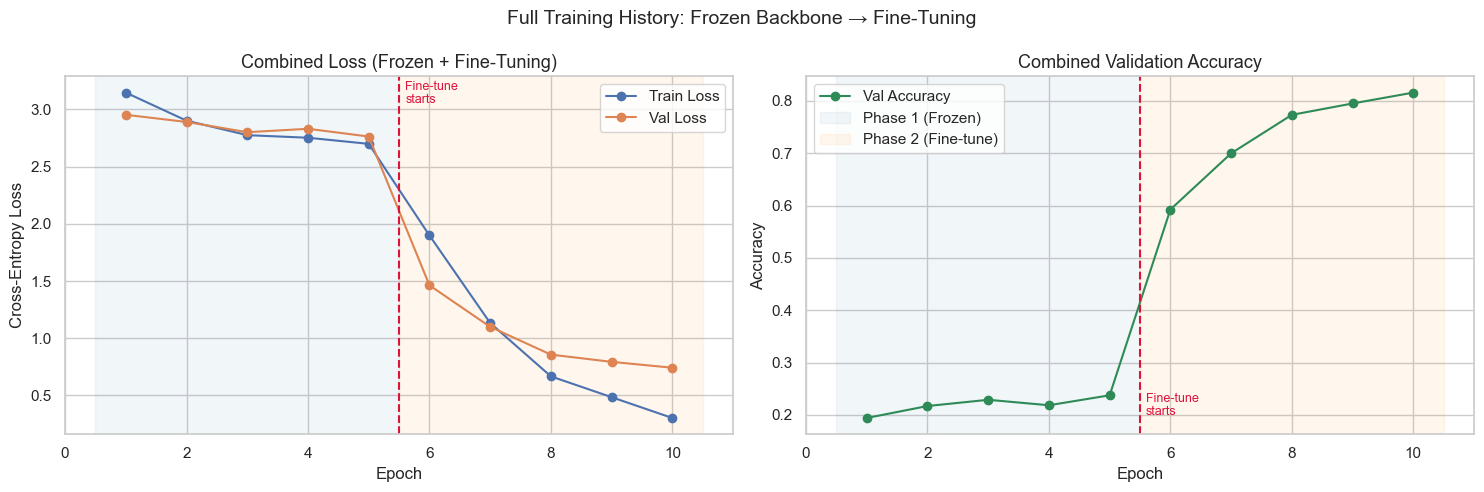

In [12]:
# Combined training curves across both phases
total_epochs  = EPOCHS_P1 + EPOCHS_P2
all_tr_loss   = hist_p1['train_loss'] + hist_p2['train_loss']
all_vl_loss   = hist_p1['val_loss']   + hist_p2['val_loss']
all_vl_acc    = hist_p1['val_acc']    + hist_p2['val_acc']
epochs_all    = list(range(1, total_epochs + 1))

split_x = EPOCHS_P1 + 0.5  # x-position of the phase boundary

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# -- Loss --
ax1.plot(epochs_all, all_tr_loss, marker='o', label='Train Loss')
ax1.plot(epochs_all, all_vl_loss, marker='o', label='Val Loss')
ax1.axvline(x=split_x, color='crimson', linestyle='--', linewidth=1.5)
ax1.text(split_x + 0.1, max(all_tr_loss) * 0.97,
         'Fine-tune\nstarts', color='crimson', fontsize=9)
ax1.axvspan(0.5, split_x, alpha=0.07, color='steelblue')
ax1.axvspan(split_x, total_epochs + 0.5, alpha=0.07, color='darkorange')
ax1.set_title('Combined Loss (Frozen + Fine-Tuning)', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend()

# -- Accuracy --
ax2.plot(epochs_all, all_vl_acc, marker='o', color='seagreen', label='Val Accuracy')
ax2.axvline(x=split_x, color='crimson', linestyle='--', linewidth=1.5)
ax2.text(split_x + 0.1, min(all_vl_acc) + 0.005,
         'Fine-tune\nstarts', color='crimson', fontsize=9)
ax2.axvspan(0.5, split_x, alpha=0.07, color='steelblue',    label='Phase 1 (Frozen)')
ax2.axvspan(split_x, total_epochs + 0.5, alpha=0.07, color='darkorange', label='Phase 2 (Fine-tune)')
ax2.set_title('Combined Validation Accuracy', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.suptitle('Full Training History: Frozen Backbone → Fine-Tuning', fontsize=14)
plt.tight_layout()
plt.show()

---
## Section 6 – Evaluation

We evaluate the trained model on the held-out test set.  
Metrics: Top-1 accuracy, Top-3 accuracy (true label in the three highest-confidence predictions), per-class precision/recall/F1, and a confusion matrix for the 10 most common brands.  
The unseen test set gives an unbiased estimate of real-world performance.

In [13]:
# Collect all predictions and softmax probabilities on the test set
model.eval()
all_probs, all_preds, all_true = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1).cpu().numpy()
        preds   = outputs.argmax(dim=1).cpu().numpy()

        all_probs.append(probs)
        all_preds.append(preds)
        all_true.append(labels.numpy())

all_probs = np.vstack(all_probs)          # (N, num_classes)
all_preds = np.concatenate(all_preds)     # (N,)
all_true  = np.concatenate(all_true)      # (N,)

# Top-1 accuracy
top1_acc = (all_preds == all_true).mean()

# Top-3 accuracy: true label is among the 3 highest-confidence predictions
top3_acc = top_k_accuracy_score(all_true, all_probs, k=3)

print(f'Test Top-1 Accuracy: {top1_acc:.4f}  ({top1_acc * 100:.2f}%)')
print(f'Test Top-3 Accuracy: {top3_acc:.4f}  ({top3_acc * 100:.2f}%)')

Test Top-1 Accuracy: 0.8244  (82.44%)
Test Top-3 Accuracy: 0.9036  (90.36%)


In [14]:
# Per-class precision, recall, and F1 score
print('Classification Report:')
print(classification_report(
    all_true, all_preds,
    target_names=class_names,
    zero_division=0
))

Classification Report:
               precision    recall  f1-score   support

        Acura       0.85      0.74      0.79       176
   Alfa Romeo       0.85      0.67      0.75        43
 Aston Martin       0.85      0.71      0.77        86
         Audi       0.86      0.88      0.87       470
          BMW       0.82      0.91      0.86       618
      Bentley       0.63      0.69      0.66       104
        Buick       0.79      0.81      0.80       145
     Cadillac       0.86      0.84      0.85       197
    Chevrolet       0.84      0.88      0.86       762
     Chrysler       0.91      0.74      0.82        85
        Dodge       0.77      0.85      0.81       202
         FIAT       0.91      0.92      0.91       134
      Ferrari       0.82      0.64      0.72        14
         Ford       0.82      0.83      0.82       662
          GMC       0.93      0.91      0.92       310
      Genesis       0.56      0.35      0.43        26
        Honda       0.84      0.83      0

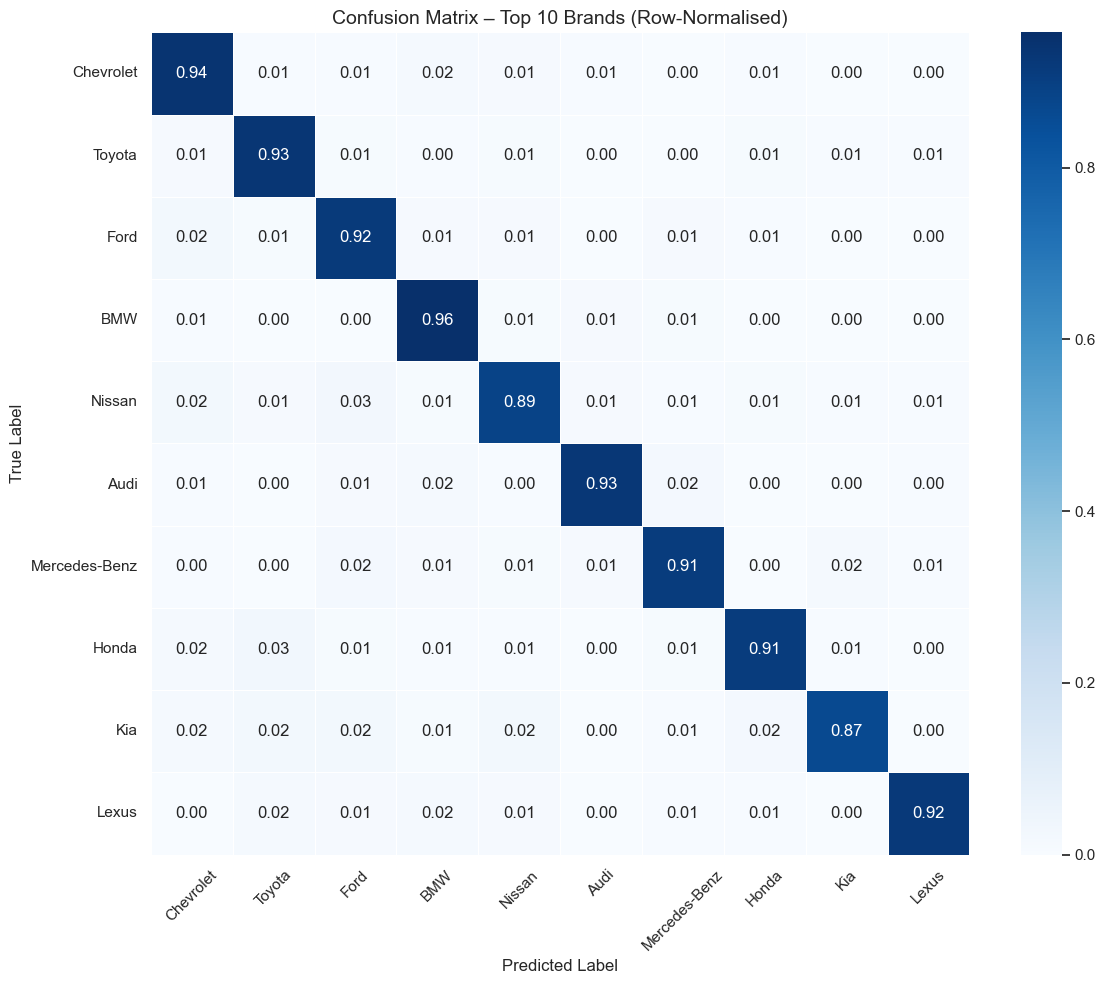

In [15]:
# Confusion matrix for the top 10 most common brands in the test set
test_brand_names = [class_names[i] for i in all_true]
top10_brands     = pd.Series(test_brand_names).value_counts().head(10).index.tolist()
top10_idx        = [class_names.index(b) for b in top10_brands]

# Filter test samples to those belonging to the top 10 brands
mask     = np.isin(all_true, top10_idx)
t10_true = all_true[mask]
t10_pred = all_preds[mask]

# Build and row-normalise confusion matrix
cm = confusion_matrix(t10_true, t10_pred, labels=top10_idx)
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm  = np.divide(cm.astype(float), row_sums,
                     where=row_sums > 0, out=np.zeros_like(cm, dtype=float))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_norm, annot=True, fmt='.2f',
            xticklabels=top10_brands, yticklabels=top10_brands,
            cmap='Blues', ax=ax, linewidths=0.4)
ax.set_title('Confusion Matrix – Top 10 Brands (Row-Normalised)', fontsize=14)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

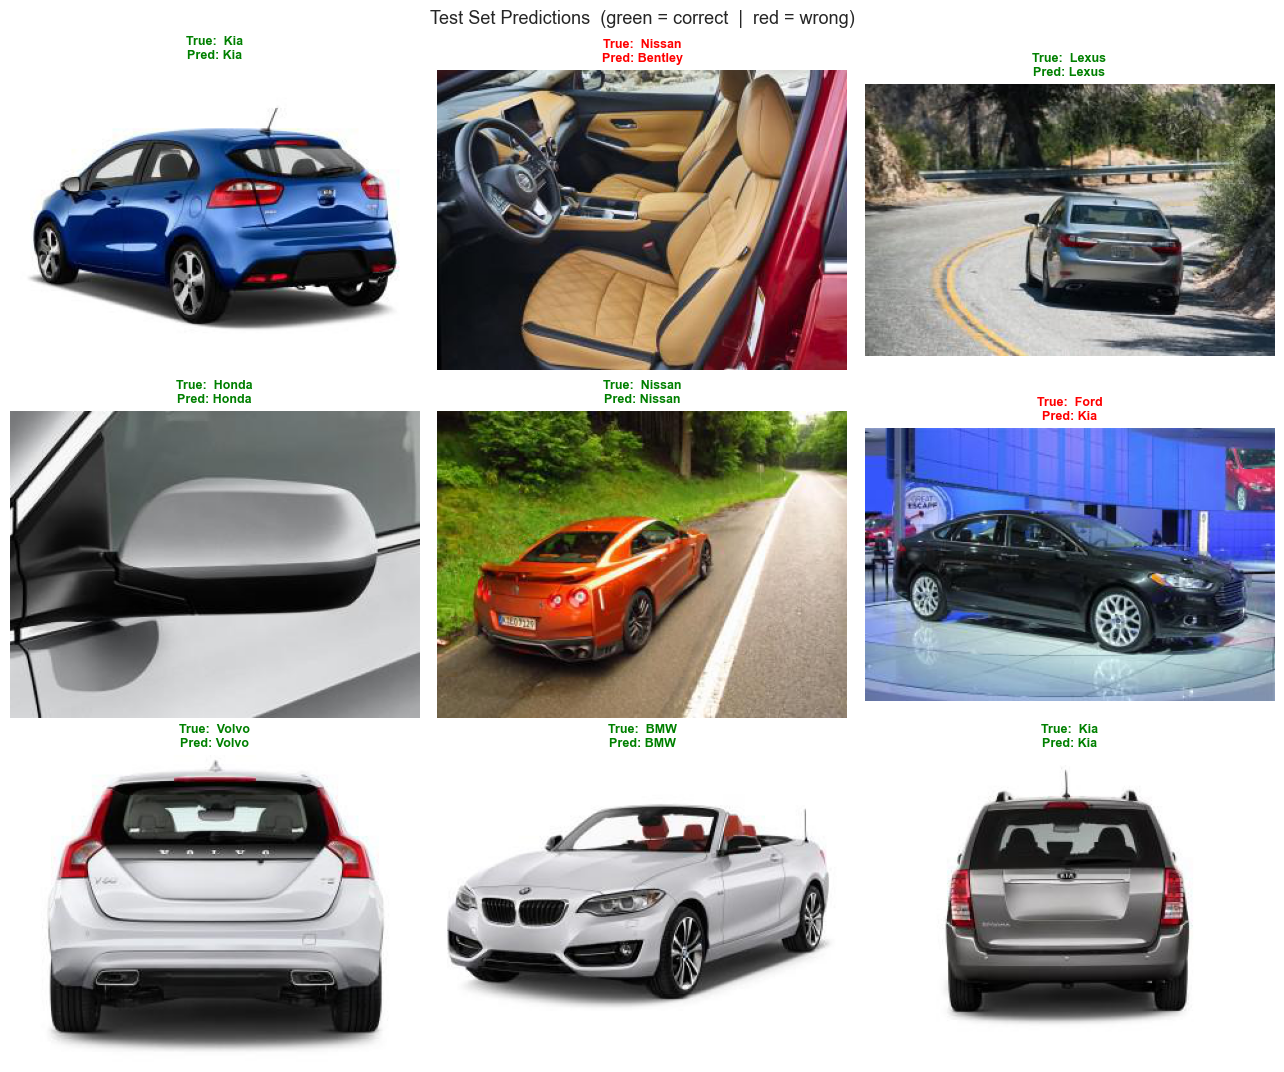

In [16]:
# Show 9 example predictions: green title = correct, red = wrong
random.seed(SEED)
sample_idx = random.sample(range(len(X_test)), 9)

fig, axes = plt.subplots(3, 3, figsize=(13, 11))
for ax, i in zip(axes.flatten(), sample_idx):
    img       = Image.open(X_test[i]).convert('RGB')
    true_name = class_names[y_test[i]]
    pred_name = class_names[all_preds[i]]
    color     = 'green' if true_name == pred_name else 'red'

    ax.imshow(img)
    ax.set_title(f'True:  {true_name}\nPred: {pred_name}',
                 color=color, fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle('Test Set Predictions  (green = correct  |  red = wrong)', fontsize=13)
plt.tight_layout()
plt.show()

### Where does the model struggle — and why?

**Brand pairs with shared heritage** — Brands owned by the same parent group (e.g. Chevrolet / GMC, Audi / Volkswagen, Lexus / Toyota) share platform components, body proportions, and design language. From a purely visual standpoint the differences are subtle, so the model frequently confuses them. The confusion matrix will show off-diagonal heat concentrated between these related pairs.

**Rare trim angles** — Some images are interior shots, close-ups of badges, or rear-three-quarter views. ResNet features trained on ImageNet (object-centred, front-facing crops) are less robust to unusual viewpoints, causing misclassifications on non-standard angles.

**Class imbalance at the edges** — Even though all brands have >= 50 images, the ratio between the largest class (Chevrolet, ~5 000 images) and the smallest is ~70×. The model has seen far more Chevrolet examples, biasing it toward predicting that label when uncertain.

**Fine-grained features vs. coarse shape** — The final brand-distinguishing cues (badge, grille surround, headlight signature) are small relative to the full image. ResNet18's global average pooling collapses spatial information, making it harder to exploit these fine-grained cues. A larger backbone (ResNet50, EfficientNet) or attention mechanisms would help.

**Possible remedies:** weighted loss to handle class imbalance, test-time augmentation to improve robustness to viewpoint, or switching to a model with explicit fine-grained recognition capabilities.

---
## Section 7 – Save Model & Label Encoder

We persist three artefacts so the Streamlit app can load the model without re-running this notebook:  
1. **`car_brand_classifier.pth`** — PyTorch model state dict (weights only, architecture must be reconstructed in the app).  
2. **`label_encoder.json`** — maps brand name → integer class index.  
3. **`class_names.json`** — ordered list of class names (index → brand name), for decoding model output.

In [17]:
os.makedirs('../models', exist_ok=True)

# 1. Model weights
model_path = '../models/car_brand_classifier.pth'
torch.save(model.state_dict(), model_path)
print(f'Model weights saved  →  {model_path}')

# 2. Label encoder: brand name → integer index
label_encoder_map = {name: int(idx) for idx, name in enumerate(class_names)}
encoder_path = '../models/label_encoder.json'
with open(encoder_path, 'w') as f:
    json.dump(label_encoder_map, f, indent=2)
print(f'Label encoder saved  →  {encoder_path}')

# 3. Class names list: integer index → brand name
class_path = '../models/class_names.json'
with open(class_path, 'w') as f:
    json.dump(class_names, f, indent=2)
print(f'Class names saved    →  {class_path}')

print(f'\nAll artefacts saved.  {num_classes} classes.')
print('To reload the model in app.py:')
print(f'  model = models.resnet18()')
print(f'  model.fc = nn.Linear(512, {num_classes})')
print(f'  model.load_state_dict(torch.load("{model_path}", map_location="cpu"))')
print(f'  model.eval()')

Model weights saved  →  ../models/car_brand_classifier.pth
Label encoder saved  →  ../models/label_encoder.json
Class names saved    →  ../models/class_names.json

All artefacts saved.  42 classes.
To reload the model in app.py:
  model = models.resnet18()
  model.fc = nn.Linear(512, 42)
  model.load_state_dict(torch.load("../models/car_brand_classifier.pth", map_location="cpu"))
  model.eval()
